# RandomForest — búsqueda de hiperparámetros (GridSearch) y batería de pruebas de overfitting

**Modelo:** `RandomForestRegressor`. A diferencia de Ridge (un solo
hiperparámetro) y de GradientBoosting (donde ya ajustaste `max_depth` y
`learning_rate` manualmente y redujo el overfitting), aquí usamos
**GridSearchCV con `TimeSeriesSplit`** para explorar sistemáticamente la
combinación de hiperparámetros anti-overfitting, en vez de probarlos uno
por uno a mano.

**Por qué `TimeSeriesSplit` y no `KFold` normal:** `KFold` mezcla el orden
de las filas al formar los folds — en series de tiempo eso dejaría que el
modelo se valide con datos "del pasado" usando información de "el futuro"
en el mismo fold (fuga de información, el mismo problema que RF03 evita en
el feature engineering). `TimeSeriesSplit` respeta el orden cronológico:
cada fold de validación es siempre posterior a su fold de entrenamieno.

**Los hiperparámetros que se exploran son, específicamente, los que
limitan qué tan "memorioso" puede volverse cada árbol individual:**
`max_depth` (profundidad máxima), `min_samples_leaf` (mínimo de muestras
por hoja — hojas más grandes = árboles menos específicos) y `max_features`
(cuántas columnas puede ver cada árbol al decidir un split — menos
columnas por árbol = más diversidad entre árboles del bosque, reduce
correlación y por lo tanto varianza del ensamble).

**Entrada:** `GET /features/history` del Data Service (mismo contrato que
los notebooks anteriores — RNF17).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 0. Carga de datos vía la API del Data Service

In [2]:
# Bootstrap: pide la data al Data Service por HTTP (tal como lo hará el
# ML Service en producción) en vez de importar DataPipeline o leer un CSV
# local. Esto valida de una vez que el contrato de la API es el correcto.
DATA_SERVICE_URL = "http://localhost:8000"  # ajusta si tu Data Service corre en otro host/puerto
PAIR_CODE = "SP500_VIX"

EXPECTED_FEATURE_COLUMNS = [
    "main_log_return", "main_log_range", "main_body_log",
    "main_upper_wick_log", "main_lower_wick_log",
    "main_vol_5d", "main_vol_10d",
    "vol_idx_log_close", "vol_idx_log_range", "vol_idx_log_return",
    "day_of_week", "target_range_next_day",
]

response = requests.get(f"{DATA_SERVICE_URL}/features/history", params={"pair_code": PAIR_CODE}, timeout=30)
response.raise_for_status()
rows = response.json()
assert rows, f"El Data Service no devolvió filas para {PAIR_CODE}."

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

missing = set(EXPECTED_FEATURE_COLUMNS) - set(df.columns)
assert not missing, f"Faltan columnas esperadas del esquema: {missing}"

versions = df["schema_version"].unique()
assert len(versions) == 1, (
    f"Se mezclaron filas de más de una versión de esquema: {versions} — "
    "RNF12: no se debe modelar sobre un esquema inconsistente."
)

print(f"Par:                {PAIR_CODE}")
print(f"Filas:              {len(df)}")
print(f"Rango de fechas:    {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Versión de esquema: {versions[0]}")

df = df.set_index("date")[EXPECTED_FEATURE_COLUMNS]

print(f"Columnas de trabajo ({len(df.columns)}): {list(df.columns)}")
df.head()


Par:                SP500_VIX
Filas:              5411
Rango de fechas:    2005-01-18 → 2026-07-22
Versión de esquema: v1
Columnas de trabajo (12): ['main_log_return', 'main_log_range', 'main_body_log', 'main_upper_wick_log', 'main_lower_wick_log', 'main_vol_5d', 'main_vol_10d', 'vol_idx_log_close', 'vol_idx_log_range', 'vol_idx_log_return', 'day_of_week', 'target_range_next_day']


,main_log_return,main_log_range,main_body_log,main_upper_wick_log,main_lower_wick_log,main_vol_5d,main_vol_10d,vol_idx_log_close,vol_idx_log_range,vol_idx_log_return,day_of_week,target_range_next_day
date,,,,,,,,,,,,
2005-01-18,0.009628,0.013367,0.009628,0.000000,0.003738,0.007942,0.006923,2.523326,0.066822,0.003213,1,0.009721
2005-01-19,-0.009535,0.009721,-0.009535,0.000000,0.000186,0.008803,0.006550,2.578701,0.062472,0.055375,2,0.009508
2005-01-20,-0.007813,0.009508,-0.007813,0.000000,0.001694,0.009138,0.006911,2.626840,0.060625,0.048140,3,0.009909
2005-01-21,-0.006435,0.009909,-0.006435,0.003431,0.000043,0.008783,0.006953,2.664447,0.076132,0.037606,4,0.007943
2005-01-24,-0.003534,0.007943,-0.003534,0.004409,0.000000,0.007681,0.006976,2.684440,0.040116,0.019994,0,0.009025


## 1. Split cronológico train/test

**Importante:** el GridSearch de la siguiente sección corre **solo dentro
de `X_train`/`y_train`**, con su propia validación cruzada interna
(`TimeSeriesSplit`). `X_test`/`y_test` no se toca hasta la Prueba 1 — ni
siquiera indirectamente a través de la búsqueda de hiperparámetros. Si el
grid search viera el test set de cualquier forma, las métricas de las
pruebas posteriores estarían infladas artificialmente.


In [3]:
FEATURE_COLS = [c for c in EXPECTED_FEATURE_COLUMNS if c != "target_range_next_day"]

X = df[FEATURE_COLS].values
y = df["target_range_next_day"].values

split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_dates = df.index[:split_idx]
test_dates = df.index[split_idx:]

print(f"Train: {len(X_train)} filas  ({train_dates.min().date()} → {train_dates.max().date()})")
print(f"Test:  {len(X_test)} filas  ({test_dates.min().date()} → {test_dates.max().date()})")


Train: 4328 filas  (2005-01-18 → 2022-03-25)
Test:  1083 filas  (2022-03-28 → 2026-07-22)


## 2. Búsqueda de hiperparámetros anti-overfitting (GridSearchCV + TimeSeriesSplit)

`return_train_score=True` es deliberado: `GridSearchCV` por defecto solo
reporta el score de validación de cada combinación. Sin el score de
entrenamiento no se puede calcular la brecha de overfitting de cada
candidato — y el candidato con mejor score de validación a secas no es
necesariamente el mejor si también tiene la brecha más grande (el mismo
error que casi cometemos al principio con GradientBoosting).


In [4]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", 0.5],
}

base_model = RandomForestRegressor(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
)

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nCombinaciones evaluadas: {len(grid_search.cv_results_['params'])}")
print(f"Mejor score de validación (RMSE): {-grid_search.best_score_:.5f}")
print(f"Mejores hiperparámetros según GridSearchCV (solo por RMSE): {grid_search.best_params_}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Combinaciones evaluadas: 24
Mejor score de validación (RMSE): 0.00733
Mejores hiperparámetros según GridSearchCV (solo por RMSE): {'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 5}


## 3. Elegir el candidato ganador mirando RMSE **y** brecha juntos

`grid_search.best_params_` optimiza únicamente el RMSE de validación — no
sabe nada de overfitting. Construimos la tabla completa con ambas métricas
por candidato y elegimos explícitamente, con el mismo criterio que usamos
para leer las gráficas de las pruebas anteriores: **el mejor RMSE de test
entre los candidatos con una brecha aceptable**, no el mejor RMSE a
secas.


In [5]:
results = pd.DataFrame(grid_search.cv_results_)
results["rmse_val"] = -results["mean_test_score"]
results["rmse_train"] = -results["mean_train_score"]
results["brecha"] = results["rmse_val"] - results["rmse_train"]

tabla_candidatos = results[["params", "rmse_train", "rmse_val", "brecha"]].sort_values("rmse_val").reset_index(drop=True)
tabla_candidatos.head(10)


,params,rmse_train,rmse_val,brecha
0,"{'max_depth': 6, 'max_features': 0.5, 'min_sam...",0.005295,0.007327,0.002032
1,"{'max_depth': 6, 'max_features': 'sqrt', 'min_...",0.005442,0.007341,0.001899
2,"{'max_depth': 5, 'max_features': 0.5, 'min_sam...",0.005511,0.007348,0.001838
3,"{'max_depth': 6, 'max_features': 0.5, 'min_sam...",0.005664,0.007359,0.001695
4,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",0.005646,0.007369,0.001724
5,"{'max_depth': 6, 'max_features': 'sqrt', 'min_...",0.005774,0.007389,0.001615
6,"{'max_depth': 5, 'max_features': 0.5, 'min_sam...",0.005782,0.007389,0.001607
7,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",0.005894,0.007411,0.001517
8,"{'max_depth': 4, 'max_features': 0.5, 'min_sam...",0.005762,0.007413,0.001652
9,"{'max_depth': 4, 'max_features': 0.5, 'min_sam...",0.005934,0.007431,0.001497


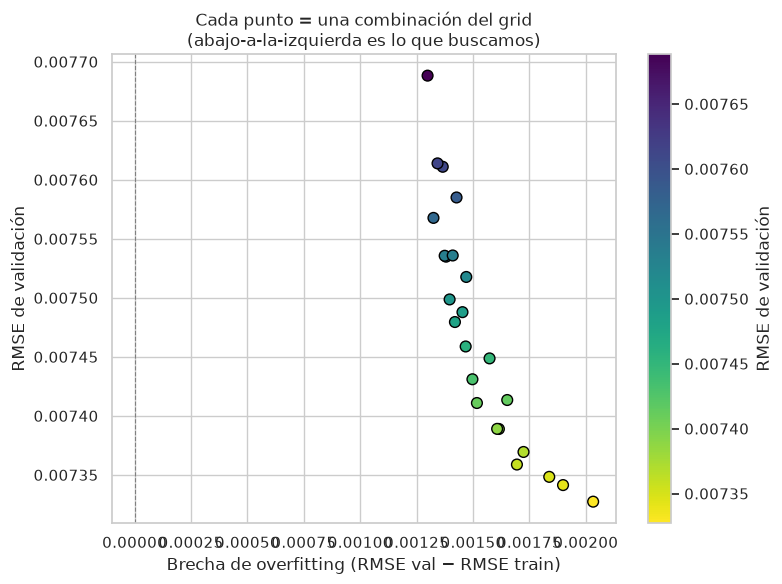

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(tabla_candidatos["brecha"], tabla_candidatos["rmse_val"],
                 c=tabla_candidatos["rmse_val"], cmap="viridis_r", s=60, edgecolor="black")
ax.set_xlabel("Brecha de overfitting (RMSE val − RMSE train)")
ax.set_ylabel("RMSE de validación")
ax.set_title("Cada punto = una combinación del grid\n(abajo-a-la-izquierda es lo que buscamos)")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.colorbar(sc, label="RMSE de validación")
plt.tight_layout()
plt.show()


In [7]:
# Criterio explícito: entre los candidatos cuya brecha no supera 1.15x la
# brecha mínima observada, elegimos el de menor RMSE de validación. Así no
# se sacrifica desempeño real por una brecha marginalmente menor, pero
# tampoco se elige ciegamente el mínimo RMSE si viene con mucho overfitting.
brecha_min = tabla_candidatos["brecha"].min()
umbral_brecha = brecha_min * 1.15 if brecha_min > 0 else brecha_min + 0.0002

candidatos_aceptables = tabla_candidatos[tabla_candidatos["brecha"] <= umbral_brecha]
mejor_candidato = candidatos_aceptables.sort_values("rmse_val").iloc[0]

print(f"Brecha mínima observada en el grid: {brecha_min:.5f}")
print(f"Umbral de brecha aceptable:         {umbral_brecha:.5f}")
print(f"Candidatos dentro del umbral:        {len(candidatos_aceptables)} de {len(tabla_candidatos)}")
print(f"\nCandidato recomendado:")
print(mejor_candidato)


Brecha mínima observada en el grid: 0.00130
Umbral de brecha aceptable:         0.00149
Candidatos dentro del umbral:        13 de 24

Candidato recomendado:
params        {'max_depth': 6, 'max_features': 0.5, 'min_sam...
rmse_train                                             0.005991
rmse_val                                               0.007459
brecha                                                 0.001467
Name: 11, dtype: object


In [8]:
HYPERPARAMS = {
    "n_estimators": 300,
    **mejor_candidato["params"],
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

def build_model(**overrides):
    """Crea una instancia nueva de RandomForestRegressor con HYPERPARAMS,
    permitiendo sobrescribir puntualmente (usado en la curva de validación
    para variar n_estimators sin tocar el resto)."""
    params = {**HYPERPARAMS, **overrides}
    return RandomForestRegressor(**params)

print("Hiperparámetros elegidos tras el GridSearch:", HYPERPARAMS)


Hiperparámetros elegidos tras el GridSearch: {'n_estimators': 300, 'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 20, 'random_state': 42, 'n_jobs': -1}


## 4. Entrenamiento base con los hiperparámetros elegidos

In [9]:
modelo = build_model()
modelo.fit(X_train, y_train)
print("Modelo entrenado con los hiperparámetros seleccionados por el GridSearch.")


Modelo entrenado con los hiperparámetros seleccionados por el GridSearch.


## Prueba 1 — RMSE, MAE y R² en train vs. test

**Qué se busca:** una brecha entre train y test en más de una métrica a la
vez. RMSE castiga errores grandes más que MAE; si una diverge y la otra no,
el modelo falla de forma distinta en errores típicos vs. extremos.

**Señal de overfitting:** `RMSE_test`/`MAE_test` notablemente peores que
train, y `R²_test` mucho menor que `R²_train`.

**Nota:** este split de train/test es el mismo que se mantuvo aislado del
GridSearch — es la primera vez que el modelo final ve el conjunto de
prueba.


In [10]:
def metricas(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

m_train = metricas(y_train, pred_train)
m_test = metricas(y_test, pred_test)

prueba1 = pd.DataFrame([
    {"conjunto": "Train", **m_train},
    {"conjunto": "Test", **m_test},
    {"conjunto": "Gap (test - train)",
     "rmse": m_test["rmse"] - m_train["rmse"],
     "mae": m_test["mae"] - m_train["mae"],
     "r2": m_test["r2"] - m_train["r2"]},
])
prueba1


,conjunto,rmse,mae,r2
0,Train,0.005863,0.003865,0.674818
1,Test,0.005530,0.003734,0.476570
2,Gap (test - train),-0.000333,-0.000130,-0.198248


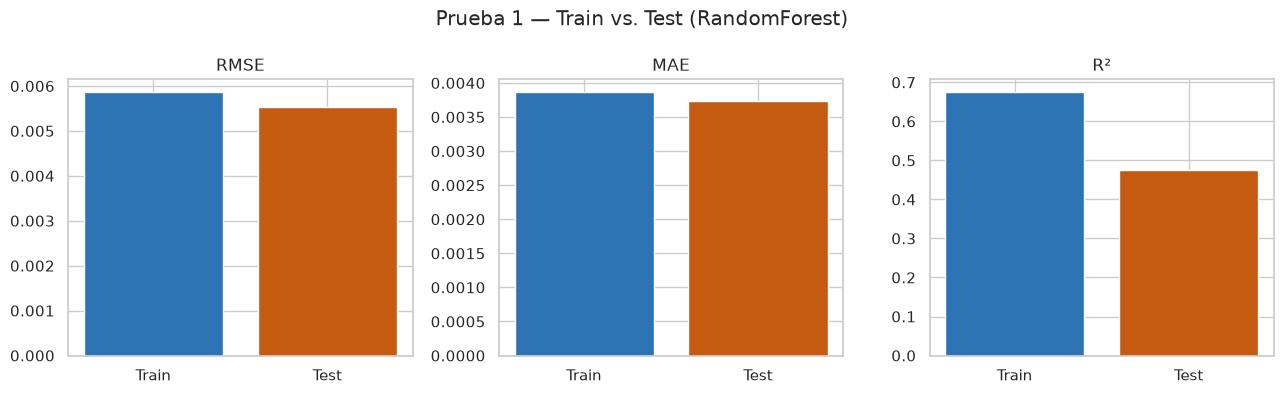

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, label in zip(axes, ["rmse", "mae", "r2"], ["RMSE", "MAE", "R²"]):
    ax.bar(["Train", "Test"], [m_train[metric], m_test[metric]], color=["#2E74B5", "#C55A11"])
    ax.set_title(label)
plt.suptitle("Prueba 1 — Train vs. Test (RandomForest)")
plt.tight_layout()
plt.show()


## Prueba 2 — Desempeño por régimen de volatilidad (normal vs. crisis)

**Qué se busca:** un RMSE agregado bueno puede esconder que el modelo
falla justo en los períodos de crisis. Los umbrales se calculan **solo con
el train**.

**Señal de overfitting:** el gap train→test es mucho peor dentro de
"Crisis" que dentro de "Normal".


In [12]:
CRISIS_QUANTILE = 0.75

umbral_crisis = np.quantile(df["vol_idx_log_close"].values[:split_idx], CRISIS_QUANTILE)
print(f"Umbral de régimen (calculado solo con train): vol_idx_log_close >= {umbral_crisis:.4f} → Crisis")

def etiquetar_regimen(vol_idx_log_close, umbral):
    return np.where(vol_idx_log_close >= umbral, "Crisis", "Normal")

regimen_train = etiquetar_regimen(df["vol_idx_log_close"].values[:split_idx], umbral_crisis)
regimen_test = etiquetar_regimen(df["vol_idx_log_close"].values[split_idx:], umbral_crisis)

def rmse_mae_por_regimen(y_true, y_pred, regimen, conjunto):
    out = []
    for r in ["Normal", "Crisis"]:
        mask = regimen == r
        if mask.sum() == 0:
            continue
        out.append({
            "conjunto": conjunto, "regimen": r, "n": int(mask.sum()),
            "rmse": np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
            "mae": mean_absolute_error(y_true[mask], y_pred[mask]),
        })
    return out

prueba2 = pd.DataFrame(
    rmse_mae_por_regimen(y_train, pred_train, regimen_train, "Train") +
    rmse_mae_por_regimen(y_test, pred_test, regimen_test, "Test")
)
prueba2


Umbral de régimen (calculado solo con train): vol_idx_log_close >= 3.1040 → Crisis


,conjunto,regimen,n,rmse,mae
0,Train,Normal,3246,0.003998,0.002947
1,Train,Crisis,1082,0.009463,0.006618
2,Test,Normal,851,0.004281,0.003154
3,Test,Crisis,232,0.008691,0.005865


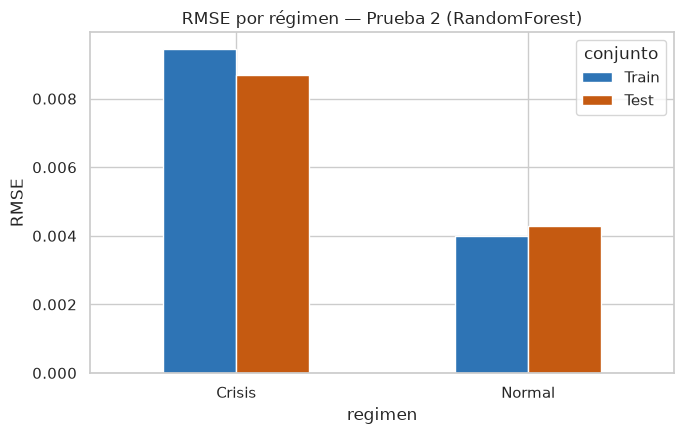


Gap (Test - Train) por régimen:
regimen
Crisis   -0.000771
Normal    0.000282
Name: gap, dtype: float64


In [13]:
pivot_rmse = prueba2.pivot(index="regimen", columns="conjunto", values="rmse")
pivot_rmse["gap"] = pivot_rmse["Test"] - pivot_rmse["Train"]

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot_rmse[["Train", "Test"]].plot(kind="bar", ax=ax, color=["#2E74B5", "#C55A11"])
ax.set_title("RMSE por régimen — Prueba 2 (RandomForest)")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("\nGap (Test - Train) por régimen:")
print(pivot_rmse["gap"])


## Prueba 3 — Curva de validación vs. `n_estimators`

**Qué se busca:** a diferencia de boosting (donde más árboles puede
sobreajustar progresivamente), RandomForest suele ser mucho más **robusto**
a `n_estimators` — cada árbol se entrena de forma independiente sobre una
muestra distinta (bagging), así que agregar más árboles típicamente
estabiliza el promedio en vez de sobreajustar más. Esta curva confirma (o
refuta) esa expectativa para tus datos específicos.

**Señal de overfitting:** si aun así el test RMSE empeora con más árboles,
es una señal de que el problema no es la cantidad de árboles sino la
profundidad/hojas — revisa si el candidato elegido por el GridSearch tiene
`max_depth`/`min_samples_leaf` demasiado permisivos.


In [14]:
n_range = [25, 50, 100, 150, 200, 250, 300, 400, 500]
curva = []
for n in n_range:
    m = build_model(n_estimators=n)
    m.fit(X_train, y_train)
    curva.append({
        "n_estimators": n,
        "rmse_train": np.sqrt(mean_squared_error(y_train, m.predict(X_train))),
        "rmse_test": np.sqrt(mean_squared_error(y_test, m.predict(X_test))),
    })
curva_df = pd.DataFrame(curva)
curva_df


,n_estimators,rmse_train,rmse_test
0,25,0.005883,0.005595
1,50,0.005878,0.005551
2,100,0.005870,0.005533
3,150,0.005874,0.005547
4,200,0.005867,0.005539
5,250,0.005868,0.005536
6,300,0.005863,0.005530
7,400,0.005859,0.005539
8,500,0.005860,0.005536


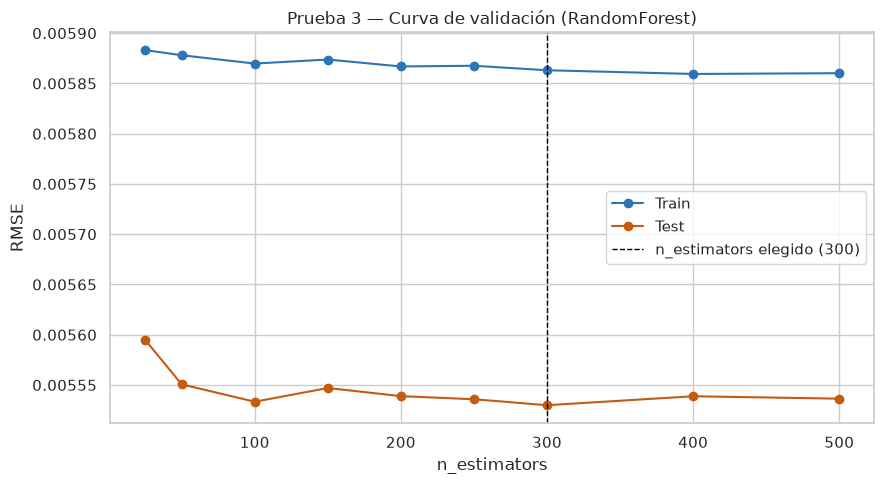

n_estimators con menor RMSE de test en esta curva: 300
n_estimators elegido: 300


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curva_df["n_estimators"], curva_df["rmse_train"], label="Train", marker="o", color="#2E74B5")
ax.plot(curva_df["n_estimators"], curva_df["rmse_test"], label="Test", marker="o", color="#C55A11")
ax.axvline(HYPERPARAMS["n_estimators"], color="black", linestyle="--", linewidth=1,
           label=f"n_estimators elegido ({HYPERPARAMS['n_estimators']})")
ax.set_xlabel("n_estimators")
ax.set_ylabel("RMSE")
ax.set_title("Prueba 3 — Curva de validación (RandomForest)")
ax.legend()
plt.tight_layout()
plt.show()

optimo = curva_df.loc[curva_df["rmse_test"].idxmin(), "n_estimators"]
print(f"n_estimators con menor RMSE de test en esta curva: {optimo}")
print(f"n_estimators elegido: {HYPERPARAMS['n_estimators']}")


## Prueba 4 — Estabilidad entre folds (Walk-Forward Validation)

**Qué se busca:** confirmar con validación cronológica propia (distinta
del `TimeSeriesSplit` usado dentro del GridSearch) que el resultado no
depende de una sola frontera train/test.

**Señal de overfitting:** brecha consistentemente positiva y de magnitud
similar en la mayoría de los folds.


In [16]:
def walk_forward_validate_mensual(df, feature_cols, target_col, build_model,
                                    extract_importance, min_train_months=24):
    """Walk-Forward Validation con reentrenamiento MENSUAL -- simula
    exactamente el escenario de produccion (RF08): al cierre de cada mes,
    el modelo se reentrena con TODO el historico disponible hasta ese
    momento, y sirve predicciones para todos los dias habiles del mes
    siguiente. Cada fold es un mes calendario real, no un bloque de filas
    de tamano arbitrario -- el mismo ciclo que correria el scheduler
    mensual del ML Service en produccion.

    min_train_months: cuantos meses de historia minima se exigen antes de
    empezar a evaluar (evita entrenar los primeros folds con muy pocos
    datos).
    """
    trabajo = df.copy()
    trabajo["_year_month"] = trabajo.index.to_period("M")
    meses = sorted(trabajo["_year_month"].unique())

    metric_rows = []
    importance_rows = []
    fold = 0
    for i in range(min_train_months, len(meses)):
        mes_test = meses[i]
        train_mask = trabajo["_year_month"] < mes_test
        test_mask = trabajo["_year_month"] == mes_test

        X_tr = trabajo.loc[train_mask, feature_cols].values
        y_tr = trabajo.loc[train_mask, target_col].values
        X_te = trabajo.loc[test_mask, feature_cols].values
        y_te = trabajo.loc[test_mask, target_col].values

        if len(X_tr) == 0 or len(X_te) == 0:
            continue

        fold += 1
        model = build_model()
        model.fit(X_tr, y_tr)
        train_pred = model.predict(X_tr)
        test_pred = model.predict(X_te)

        metric_rows.append({
            "fold": fold, "mes": str(mes_test),
            "n_train": len(y_tr), "n_test": len(y_te),
            "train_rmse": np.sqrt(mean_squared_error(y_tr, train_pred)),
            "test_rmse": np.sqrt(mean_squared_error(y_te, test_pred)),
            "train_mae": mean_absolute_error(y_tr, train_pred),
            "test_mae": mean_absolute_error(y_te, test_pred),
        })
        importance_rows.append({
            "fold": fold, "mes": str(mes_test),
            **dict(zip(feature_cols, extract_importance(model))),
        })

    return pd.DataFrame(metric_rows), pd.DataFrame(importance_rows)


fold_metrics, fold_importances = walk_forward_validate_mensual(
    df, FEATURE_COLS, "target_range_next_day", build_model,
    extract_importance=lambda m: m.feature_importances_,
    min_train_months=24,  # ~2 años de historia minima antes del primer mes evaluado
)
fold_metrics["brecha_rmse"] = fold_metrics["test_rmse"] - fold_metrics["train_rmse"]
print(f"Meses evaluados (cada uno = un reentrenamiento simulado): {len(fold_metrics)}")
fold_metrics.head(10)


Meses evaluados (cada uno = un reentrenamiento simulado): 235


,fold,mes,n_train,n_test,train_rmse,test_rmse,train_mae,test_mae,brecha_rmse
0,1,2007-01,493,20,0.003021,0.002440,0.002340,0.001922,-0.000581
1,2,2007-02,513,19,0.002999,0.008589,0.002321,0.004331,0.005590
2,3,2007-03,532,22,0.003312,0.004362,0.002393,0.003293,0.001049
3,4,2007-04,554,20,0.003333,0.002674,0.002413,0.002323,-0.000659
4,5,2007-05,574,22,0.003304,0.003064,0.002394,0.002578,-0.000240
5,6,2007-06,596,21,0.003281,0.003411,0.002384,0.002800,0.000130
6,7,2007-07,617,21,0.003254,0.007765,0.002376,0.006295,0.004511
7,8,2007-08,638,23,0.003438,0.008733,0.002487,0.006913,0.005296
8,9,2007-09,661,19,0.003620,0.006776,0.002619,0.005983,0.003156
9,10,2007-10,680,23,0.003701,0.006375,0.002676,0.005415,0.002674


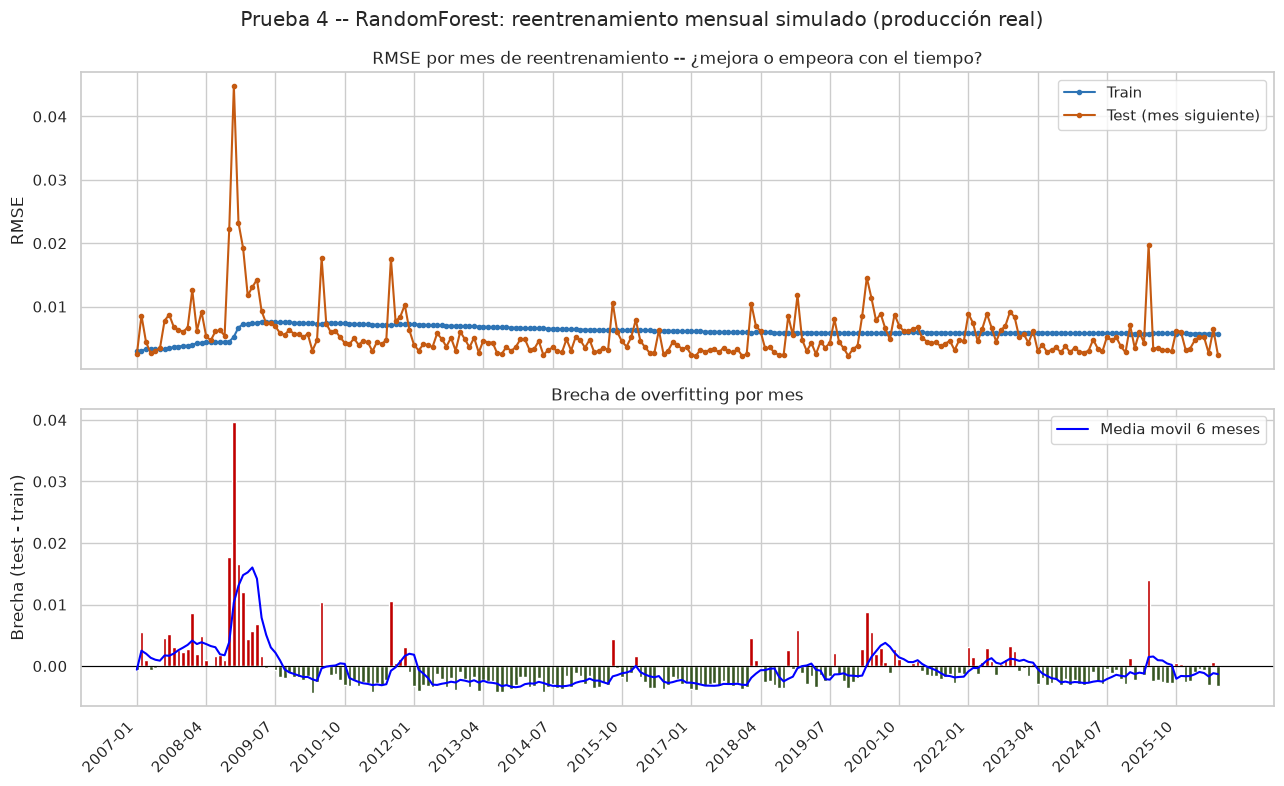

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(fold_metrics["mes"], fold_metrics["train_rmse"], label="Train", color="#2E74B5", marker="o", markersize=3)
axes[0].plot(fold_metrics["mes"], fold_metrics["test_rmse"], label="Test (mes siguiente)", color="#C55A11", marker="o", markersize=3)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE por mes de reentrenamiento -- ¿mejora o empeora con el tiempo?")
axes[0].legend()

colors = ["#C00000" if v > 0 else "#375623" for v in fold_metrics["brecha_rmse"]]
axes[1].bar(fold_metrics["mes"], fold_metrics["brecha_rmse"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
media_movil = fold_metrics["brecha_rmse"].rolling(6, min_periods=1).mean()
axes[1].plot(fold_metrics["mes"], media_movil.values, color="blue", linewidth=1.5, label="Media movil 6 meses")
axes[1].set_ylabel("Brecha (test - train)")
axes[1].set_title("Brecha de overfitting por mes")
axes[1].legend()

n_ticks = 15
step = max(1, len(fold_metrics) // n_ticks)
for ax in axes:
    ax.set_xticks(range(0, len(fold_metrics), step))
    ax.set_xticklabels(fold_metrics["mes"].iloc[::step], rotation=45, ha="right")

plt.suptitle("Prueba 4 -- RandomForest: reentrenamiento mensual simulado (producción real)")
plt.tight_layout()
plt.show()


## Prueba 5 — Estabilidad de la importancia de variables entre folds

**Qué se busca:** si el ranking de variables más importantes cambia mucho
de un fold a otro, el modelo no está aprendiendo una relación estable.

**Señal de overfitting:** variables con importancia alta en un fold y casi
nula en el siguiente (coeficiente de variación alto).


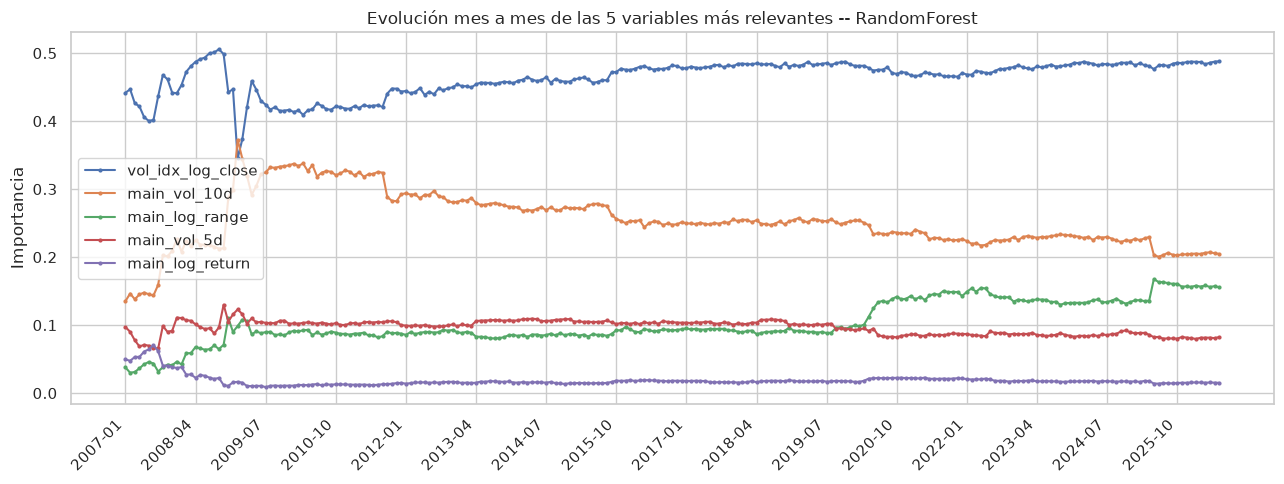

In [18]:
imp_matrix = fold_importances.set_index("mes")[FEATURE_COLS]

# Con potencialmente muchos meses, un heatmap se vuelve ilegible -- se
# grafica la evolucion temporal de las top-5 variables en vez de una
# matriz completa.
top_features = imp_matrix.mean().sort_values(ascending=False).index[:5]

fig, ax = plt.subplots(figsize=(13, 5))
for feat in top_features:
    ax.plot(range(len(imp_matrix)), imp_matrix[feat].values, label=feat, marker="o", markersize=2)

step = max(1, len(imp_matrix) // 15)
ax.set_xticks(range(0, len(imp_matrix), step))
ax.set_xticklabels(imp_matrix.index[::step], rotation=45, ha="right")
ax.set_ylabel("Importancia")
ax.set_title("Evolución mes a mes de las 5 variables más relevantes -- RandomForest")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
estabilidad = pd.DataFrame({
    "media": imp_matrix.mean(),
    "std": imp_matrix.std(),
})
estabilidad["coef_variacion"] = estabilidad["std"] / estabilidad["media"].replace(0, np.nan)
estabilidad = estabilidad.sort_values("coef_variacion", ascending=False)
estabilidad


,media,std,coef_variacion
day_of_week,0.001863,0.003965,2.128686
main_body_log,0.015880,0.010939,0.688869
vol_idx_log_range,0.010266,0.006569,0.639881
main_upper_wick_log,0.013137,0.008258,0.628600
main_lower_wick_log,0.016026,0.009254,0.577418
vol_idx_log_return,0.007658,0.003891,0.508130
main_log_return,0.018632,0.008720,0.468008
main_log_range,0.103167,0.030767,0.298223
main_vol_10d,0.253216,0.041762,0.164927
main_vol_5d,0.096575,0.010453,0.108232


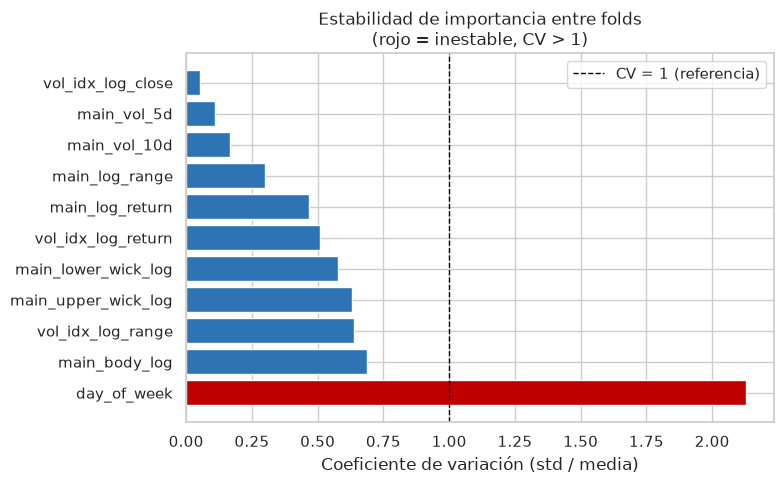

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C00000" if v > 1 else "#2E74B5" for v in estabilidad["coef_variacion"]]
ax.barh(estabilidad.index, estabilidad["coef_variacion"], color=colors)
ax.axvline(1, color="black", linestyle="--", linewidth=1, label="CV = 1 (referencia)")
ax.set_xlabel("Coeficiente de variación (std / media)")
ax.set_title("Estabilidad de importancia entre folds\n(rojo = inestable, CV > 1)")
ax.legend()
plt.tight_layout()
plt.show()


## Resumen de las 5 pruebas — RandomForest

| Prueba | Qué mirar | ¿Hay señal de overfitting? |
|---|---|---|
| 1 — Train vs Test | Gap de RMSE, MAE y R² simultáneamente | |
| 2 — Por régimen | Gap específicamente en "Crisis" | |
| 3 — Curva de validación | ¿El test RMSE se mantiene estable con más árboles? | |
| 4 — Walk-Forward | ¿La brecha es consistente entre folds o la domina uno solo? | |
| 5 — Importancia por fold | ¿Hay variables con CV > 1? | |

**Hiperparámetros finales elegidos por el GridSearch** (revisa la sección
2-3 arriba para ver el trade-off completo entre RMSE y brecha de todos los
candidatos evaluados, no solo el ganador):


In [21]:
print(HYPERPARAMS)


{'n_estimators': 300, 'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 20, 'random_state': 42, 'n_jobs': -1}


Compara esta tabla y estos hiperparámetros contra los de Ridge y
GradientBoosting antes de decidir qué modelo pasa a la Fase 4 del plan del
ML Service (compuerta de validación antes de promover a producción).
